# Projet Master 2 IEF 2025/2026 — Data Science

## Prédiction de `spot_id_delta`

Ce notebook répond de manière argumentée aux différentes questions du projet de data science.

### Objectif
L'objectif est de prédire la variable cible `spot_id_delta` à partir de variables explicatives liées au marché de l'électricité, en construisant successivement :
- un benchmark simple,
- un modèle de référence supervisé,
- un modèle non supervisé,
- un modèle supervisé plus avancé.

L'évaluation repose principalement sur la **Weighted Accuracy (WA)**, qui mesure la qualité de la prédiction du signe de la cible en pondérant par l'amplitude réelle des variations.

In [5]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVR

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

## 1. Problématique du challenge

Le challenge étudié est un problème de **régression** : il s'agit d'expliquer et de prédire la variable `spot_id_delta`, qui représente une variation de prix spot.

La difficulté principale provient de trois éléments :
1. la structure temporelle des données ;
2. l'hétérogénéité des variables explicatives ;
3. l'importance économique du **signe** de la variation, davantage que de sa seule amplitude.

Pour répondre à cette problématique, la démarche retenue est la suivante :
- charger et nettoyer les données ;
- construire quelques variables explicatives simples mais pertinentes ;
- mettre en place un découpage chronologique rigoureux ;
- entraîner un modèle de référence supervisé ;
- construire un modèle non supervisé de type clustering ;
- construire un modèle supervisé plus flexible de type SVR ;
- comparer les performances obtenues.

In [6]:
TIME_COL = "DELIVERY_START"
TARGET_COL = "spot_id_delta"

@dataclass
class RawData:
    x_train: pd.DataFrame
    y_train: pd.DataFrame
    x_test: pd.DataFrame


def _robust_read_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [str(c).strip() for c in df.columns]

    if df.shape[1] == 1 and "," in df.columns[0]:
        df = pd.read_csv(path, sep=",", engine="python")
        df.columns = [str(c).strip() for c in df.columns]

    return df


def load_raw_data(data_dir: Path) -> RawData:
    x_train = _robust_read_csv(data_dir / "X_train.csv")
    y_train = _robust_read_csv(data_dir / "y_train.csv")
    x_test = _robust_read_csv(data_dir / "X_test.csv")
    return RawData(x_train=x_train, y_train=y_train, x_test=x_test)


def merge_train_xy(x_train: pd.DataFrame, y_train: pd.DataFrame) -> pd.DataFrame:
    return x_train.merge(y_train, on=TIME_COL, how="inner").sort_values(TIME_COL).reset_index(drop=True)

## 2. Décomposition de la base en train / test / validation

Comme il s'agit d'une série temporelle, le découpage doit impérativement respecter l'ordre chronologique afin d'éviter toute fuite d'information (look-ahead bias).

La base fournie contient déjà :
- un échantillon d'entraînement (`X_train`, `y_train`) ;
- un échantillon de test (`X_test`).

Ensuite, l'échantillon d'entraînement est lui-même décomposé en :
- une base d'estimation ;
- une base de validation chronologique.

In [13]:
def normalize_datetime(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out[TIME_COL] = pd.to_datetime(out[TIME_COL], errors="coerce", utc=True)
    invalid = int(out[TIME_COL].isna().sum())
    if invalid > 0:
        raise ValueError(f"{invalid} lignes ont un DELIVERY_START invalide après parsing datetime")
    out[TIME_COL] = out[TIME_COL].dt.tz_convert("UTC").dt.tz_localize(None)
    return out


def fix_column_names(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "nucelear_power_available" in out.columns and "nuclear_power_available" not in out.columns:
        out = out.rename(columns={"nucelear_power_available": "nuclear_power_available"})
    return out


def add_datetime_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour"] = out[TIME_COL].dt.hour
    out["dayofweek"] = out[TIME_COL].dt.dayofweek
    out["month"] = out[TIME_COL].dt.month
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out


def add_lag_features(df: pd.DataFrame, columns: Iterable[str], lags: Iterable[int]) -> pd.DataFrame:
    out = df.copy().sort_values(TIME_COL).reset_index(drop=True)
    for col in columns:
        if col not in out.columns:
            continue
        for lag in lags:
            out[f"{col}_lag_{lag}"] = out[col].shift(lag)
    return out


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = normalize_datetime(df)
    out = fix_column_names(out)
    out = add_datetime_features(out)
    out = add_lag_features(
        out,
        columns=[
            "load_forecast",
            "gas_power_available",
            "wind_power_forecasts_average",
            "solar_power_forecasts_average",
            "wind_power_forecasts_std",
            "solar_power_forecasts_std",
        ],
        lags=[1, 24],
    )
    return out


@dataclass
class TrainValidSplit:
    train_df: pd.DataFrame
    valid_df: pd.DataFrame


def chronological_train_valid_split(df: pd.DataFrame, valid_fraction: float = 0.2) -> TrainValidSplit:
    if not 0 < valid_fraction < 1:
        raise ValueError("valid_fraction doit être dans ]0,1[.")
    cut = int(len(df) * (1 - valid_fraction))
    train_df = df.iloc[:cut].copy()
    valid_df = df.iloc[cut:].copy()
    return TrainValidSplit(train_df=train_df, valid_df=valid_df)

In [14]:
DATA_DIR = Path("data")

raw = load_raw_data(DATA_DIR)

train_full = merge_train_xy(raw.x_train, raw.y_train)
train_full = build_features(train_full)
test_full = build_features(raw.x_test)

split = chronological_train_valid_split(train_full, valid_fraction=0.2)
train_df = split.train_df
valid_df = split.valid_df

print("Dimensions")
print("train complet :", train_full.shape)
print("train estimation :", train_df.shape)
print("validation :", valid_df.shape)
print("test :", test_full.shape)

display(train_full.head())

Dimensions
train complet : (10605, 31)
train estimation : (8484, 31)
validation : (2121, 31)
test : (4942, 30)


,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nuclear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,spot_id_delta,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,load_forecast_lag_1,load_forecast_lag_24,gas_power_available_lag_1,gas_power_available_lag_24,wind_power_forecasts_average_lag_1,wind_power_forecasts_average_lag_24,solar_power_forecasts_average_lag_1,solar_power_forecasts_average_lag_24,wind_power_forecasts_std_lag_1,wind_power_forecasts_std_lag_24,solar_power_forecasts_std_lag_1,solar_power_forecasts_std_lag_24
0,2022-01-01 01:00:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.0,NaN,-36.874770,1,5,1,1,0.258819,0.965926,-0.974928,-0.222521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 02:00:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.0,NaN,-12.643588,2,5,1,1,0.500000,0.866025,-0.974928,-0.222521,49439.0,NaN,11487.0,NaN,3035.0,NaN,0.0,NaN,79.248348,NaN,0.0,NaN
2,2022-01-01 03:00:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.0,NaN,-1.950193,3,5,1,1,0.707107,0.707107,-0.974928,-0.222521,46511.0,NaN,11487.0,NaN,3143.0,NaN,0.0,NaN,61.776532,NaN,0.0,NaN
3,2022-01-01 04:00:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.0,NaN,1.938272,4,5,1,1,0.866025,0.500000,-0.974928,-0.222521,45158.0,NaN,11487.0,NaN,3288.0,NaN,0.0,NaN,44.291112,NaN,0.0,NaN
4,2022-01-01 05:00:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.0,NaN,0.199907,5,5,1,1,0.965926,0.258819,-0.974928,-0.222521,44779.0,NaN,11487.0,NaN,3447.0,NaN,0.0,NaN,36.127588,NaN,0.0,NaN


In [15]:
print("Périodes observées")
print("Train complet :", train_full[TIME_COL].min(), "->", train_full[TIME_COL].max())
print("Train estimation :", train_df[TIME_COL].min(), "->", train_df[TIME_COL].max())
print("Validation :", valid_df[TIME_COL].min(), "->", valid_df[TIME_COL].max())
print("Test :", test_full[TIME_COL].min(), "->", test_full[TIME_COL].max())

overlap = pd.to_datetime(valid_df[TIME_COL]).min() <= pd.to_datetime(train_df[TIME_COL]).max()
print("Fuite temporelle détectée ?" , overlap)

Périodes observées
Train complet : 2022-01-01 01:00:00 -> 2023-03-29 21:00:00
Train estimation : 2022-01-01 01:00:00 -> 2022-12-30 12:00:00
Validation : 2022-12-30 13:00:00 -> 2023-03-29 21:00:00
Test : 2023-04-01 22:00:00 -> 2023-10-24 21:00:00
Fuite temporelle détectée ? False


### Commentaire sur le découpage

Le split retenu est strictement chronologique.  
Ainsi, l'échantillon de validation est postérieur à l'échantillon d'estimation, ce qui permet d'évaluer les modèles dans un cadre réaliste et d'éviter les fuites temporelles.

## 3. Construction et description des features

Les variables explicatives construites dans ce notebook restent volontairement simples, conformément à la consigne du projet.

Les principales familles de variables utilisées sont :
- variables calendaires : heure, jour de semaine, mois, week-end ;
- variables cycliques : sinus et cosinus des cycles journaliers et hebdomadaires ;
- retards (lags) sur certaines variables fondamentales du marché :
  - `load_forecast`
  - `gas_power_available`
  - `wind_power_forecasts_average`
  - `solar_power_forecasts_average`
  - `wind_power_forecasts_std`
  - `solar_power_forecasts_std`

L'idée est de capturer à la fois :
- la saisonnalité intrajournalière,
- la saisonnalité hebdomadaire,
- la persistance des signaux fondamentaux.

In [16]:
def build_feature_stats(df: pd.DataFrame, top_n: int = 25) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=["number"]).columns
    stats = df[numeric_cols].describe().T
    stats["missing_ratio"] = df[numeric_cols].isna().mean()
    stats = stats.sort_values("std", ascending=False)
    return stats.head(top_n)

feature_stats = build_feature_stats(train_df, top_n=25)
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max,missing_ratio
load_forecast_lag_24,7197.0,52277.576490,11415.798825,30515.000000,43701.000000,5.010400e+04,60454.000000,85145.000000,0.151697
load_forecast_lag_1,7220.0,52276.947645,11399.158801,30515.000000,43740.250000,5.012000e+04,60425.000000,85145.000000,0.148986
load_forecast,7221.0,52277.454092,11398.450602,30515.000000,43741.000000,5.012100e+04,60425.000000,85145.000000,0.148868
nuclear_power_available,8483.0,33695.354592,7414.069136,22285.000000,28620.000000,3.071000e+04,38897.000000,50122.000000,0.000118
wind_power_forecasts_average,8460.0,4065.728605,3019.734513,592.000000,1898.750000,3.017000e+03,5266.000000,14629.000000,0.002829
wind_power_forecasts_average_lag_1,8459.0,4064.479844,3017.727710,592.000000,1898.500000,3.017000e+03,5264.000000,14613.000000,0.002947
wind_power_forecasts_average_lag_24,8436.0,4050.704955,3006.632744,592.000000,1895.500000,3.008000e+03,5235.000000,14613.000000,0.005658
solar_power_forecasts_average_lag_24,8460.0,2010.341726,2774.798800,0.000000,0.000000,2.120000e+02,3730.500000,10127.000000,0.002829
solar_power_forecasts_average_lag_1,8483.0,2005.888365,2772.539150,0.000000,0.000000,2.090000e+02,3714.500000,10127.000000,0.000118
solar_power_forecasts_average,8484.0,2005.873527,2772.376065,0.000000,0.000000,2.090000e+02,3713.750000,10127.000000,0.000000


In [17]:
target_desc = train_df[TARGET_COL].describe()
display(target_desc.to_frame(name="spot_id_delta"))

,spot_id_delta
count,8484.000000
mean,0.283605
std,41.748380
min,-1567.353547
25%,-14.405631
50%,-0.773811
75%,12.759053
max,658.961329


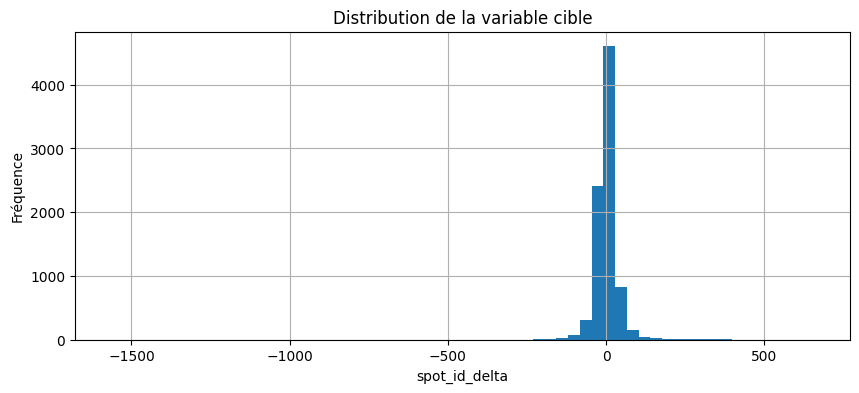

In [18]:
plt.figure(figsize=(10,4))
train_df[TARGET_COL].hist(bins=60)
plt.title("Distribution de la variable cible")
plt.xlabel(TARGET_COL)
plt.ylabel("Fréquence")
plt.show()

In [19]:
selected_cols = [
    TARGET_COL,
    "load_forecast",
    "gas_power_available",
    "wind_power_forecasts_average",
    "solar_power_forecasts_average",
    "hour",
    "dayofweek"
]

corr_df = train_df[selected_cols].select_dtypes(include=["number"]).corr()
display(corr_df)

,spot_id_delta,load_forecast,gas_power_available,wind_power_forecasts_average,solar_power_forecasts_average,hour,dayofweek
spot_id_delta,1.000000,0.027452,-0.022387,-0.016995,0.004026,0.021516,-0.020878
load_forecast,0.027452,1.000000,0.476579,0.104866,-0.011696,0.130379,-0.165539
gas_power_available,-0.022387,0.476579,1.000000,0.352182,-0.234792,0.015124,-0.041361
wind_power_forecasts_average,-0.016995,0.104866,0.352182,1.000000,-0.235057,0.048591,-0.008929
solar_power_forecasts_average,0.004026,-0.011696,-0.234792,-0.235057,1.000000,-0.015493,0.007499
hour,0.021516,0.130379,0.015124,0.048591,-0.015493,1.000000,-0.000096
dayofweek,-0.020878,-0.165539,-0.041361,-0.008929,0.007499,-0.000096,1.000000


### Commentaire sur les features

Les statistiques descriptives mettent en évidence plusieurs variables très dispersées, notamment celles liées à la demande (`load_forecast`) et à la disponibilité de certaines capacités de production (`gas_power_available`).

Les variables calendaires jouent également un rôle important, car le marché de l'électricité présente des profils très marqués selon l'heure de la journée et le jour de la semaine.

Enfin, les variables retardées permettent d'introduire une mémoire courte dans le modèle, ce qui est pertinent dans un cadre de séries temporelles.

## 4. Modèle simple de référence

Le modèle de référence choisi est une **Ridge Regression**.  
Ce choix présente plusieurs avantages :
- méthode simple et interprétable ;
- adaptée à un grand nombre de variables numériques ;
- plus stable qu'une régression linéaire pure en présence de colinéarité.

En parallèle, on compare aussi les résultats à un benchmark extrêmement simple : prédire un delta toujours positif.

In [20]:
def weighted_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true et y_pred doivent avoir la même forme")

    correct_sign = (np.sign(y_true) == np.sign(y_pred)).astype(float)
    weights = np.abs(y_true)
    denom = weights.sum()

    if denom == 0:
        return float(correct_sign.mean())
    return float((correct_sign * weights).sum() / denom)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.Series:
    return pd.Series({
        "WA": float(weighted_accuracy(y_true, y_pred)),
        "RMSE": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
    })


def always_positive_baseline(df: pd.DataFrame, positive_value: float = 1.0) -> pd.DataFrame:
    return pd.DataFrame({
        TIME_COL: df[TIME_COL],
        TARGET_COL: np.full(len(df), positive_value)
    })

In [21]:
@dataclass
class Preprocessor:
    feature_cols: list[str]
    medians: np.ndarray
    means: np.ndarray
    stds: np.ndarray


@dataclass
class RidgeReferenceModel:
    alpha: float
    preprocessor: Preprocessor
    coef_: np.ndarray
    intercept_: float


def select_feature_columns(df: pd.DataFrame) -> list[str]:
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    return [c for c in numeric_cols if c != TARGET_COL]


def fit_preprocessor(df: pd.DataFrame, feature_cols: list[str]) -> Preprocessor:
    x = df[feature_cols].to_numpy(dtype=float)
    x[~np.isfinite(x)] = np.nan
    medians = np.nanmedian(x, axis=0)
    medians = np.where(np.isnan(medians), 0.0, medians)

    x_imputed = np.where(np.isnan(x), medians, x)
    means = x_imputed.mean(axis=0)
    stds = x_imputed.std(axis=0)
    stds[stds == 0] = 1.0

    return Preprocessor(feature_cols=feature_cols, medians=medians, means=means, stds=stds)


def transform_features(df: pd.DataFrame, prep: Preprocessor) -> np.ndarray:
    x = df[prep.feature_cols].to_numpy(dtype=float)
    x[~np.isfinite(x)] = np.nan
    x = np.where(np.isnan(x), prep.medians, x)
    return (x - prep.means) / prep.stds


def fit_ridge(train_df: pd.DataFrame, valid_df: pd.DataFrame, alphas: list[float], scorer):
    feature_cols = select_feature_columns(train_df)
    prep = fit_preprocessor(train_df, feature_cols)

    x_train = transform_features(train_df, prep)
    y_train = train_df[TARGET_COL].to_numpy(dtype=float)

    x_valid = transform_features(valid_df, prep)
    y_valid = valid_df[TARGET_COL].to_numpy(dtype=float)

    n_features = x_train.shape[1]
    eye = np.eye(n_features, dtype=float)
    xtx = x_train.T @ x_train
    xty = x_train.T @ y_train

    rows = []
    best = None
    best_score = -np.inf
    best_rmse = np.inf

    for alpha in alphas:
        safe_alpha = max(float(alpha), 1e-8)
        beta = np.linalg.solve(xtx + safe_alpha * eye, xty)
        intercept = float(y_train.mean())

        y_pred = x_valid @ beta + intercept
        score = float(scorer(y_valid, y_pred))
        rmse = float(np.sqrt(np.mean((y_valid - y_pred) ** 2)))
        mae = float(np.mean(np.abs(y_valid - y_pred)))

        rows.append({"alpha": float(alpha), "weighted_accuracy": score, "rmse": rmse, "mae": mae})

        if (score > best_score) or (np.isclose(score, best_score) and rmse < best_rmse):
            best_score = score
            best_rmse = rmse
            best = RidgeReferenceModel(alpha=float(alpha), preprocessor=prep, coef_=beta, intercept_=intercept)

    diagnostics = pd.DataFrame(rows).sort_values(["weighted_accuracy", "rmse"], ascending=[False, True])
    return best, diagnostics


def predict_ridge(df: pd.DataFrame, model: RidgeReferenceModel) -> pd.DataFrame:
    x = transform_features(df, model.preprocessor)
    y_pred = x @ model.coef_ + model.intercept_
    return pd.DataFrame({TIME_COL: df[TIME_COL], TARGET_COL: y_pred})

In [22]:
alpha_grid = [0.01, 0.1, 1, 10, 100]
ridge_model, ridge_diag = fit_ridge(train_df, valid_df, alpha_grid, weighted_accuracy)

display(ridge_diag)
print("Alpha retenu :", ridge_model.alpha)

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


,alpha,weighted_accuracy,rmse,mae
2,1.00,0.466138,18.027602,12.672909
1,0.10,0.465611,18.031307,12.676202
0,0.01,0.465611,18.031682,12.676537
3,10.00,0.463795,17.994737,12.643305
4,100.00,0.460600,17.842892,12.497516


Alpha retenu : 1.0


In [23]:
def apply_calibration(y_pred: np.ndarray, strategy: str = "positive_clip") -> np.ndarray:
    if strategy == "positive_clip":
        return np.where(y_pred <= 0, 0.1, y_pred)
    if strategy == "always_positive_1":
        return np.full_like(y_pred, 1.0)
    return y_pred

baseline_valid = always_positive_baseline(valid_df)
ridge_valid_raw = predict_ridge(valid_df, ridge_model)
ridge_valid_clip = ridge_valid_raw.copy()
ridge_valid_clip[TARGET_COL] = apply_calibration(ridge_valid_clip[TARGET_COL].to_numpy(), "positive_clip")

comparison_ref = pd.DataFrame({
    "Modèle": ["Baseline toujours positive", "Ridge brute", "Ridge + positive_clip"],
    "WA": [
        regression_metrics(valid_df[TARGET_COL], baseline_valid[TARGET_COL])["WA"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_raw[TARGET_COL])["WA"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_clip[TARGET_COL])["WA"],
    ],
    "RMSE": [
        regression_metrics(valid_df[TARGET_COL], baseline_valid[TARGET_COL])["RMSE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_raw[TARGET_COL])["RMSE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_clip[TARGET_COL])["RMSE"],
    ],
    "MAE": [
        regression_metrics(valid_df[TARGET_COL], baseline_valid[TARGET_COL])["MAE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_raw[TARGET_COL])["MAE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_clip[TARGET_COL])["MAE"],
    ],
})

display(comparison_ref)

,Modèle,WA,RMSE,MAE
0,Baseline toujours positive,0.658359,16.795445,11.190255
1,Ridge brute,0.466138,18.027602,12.672909
2,Ridge + positive_clip,0.658359,16.783985,11.300921


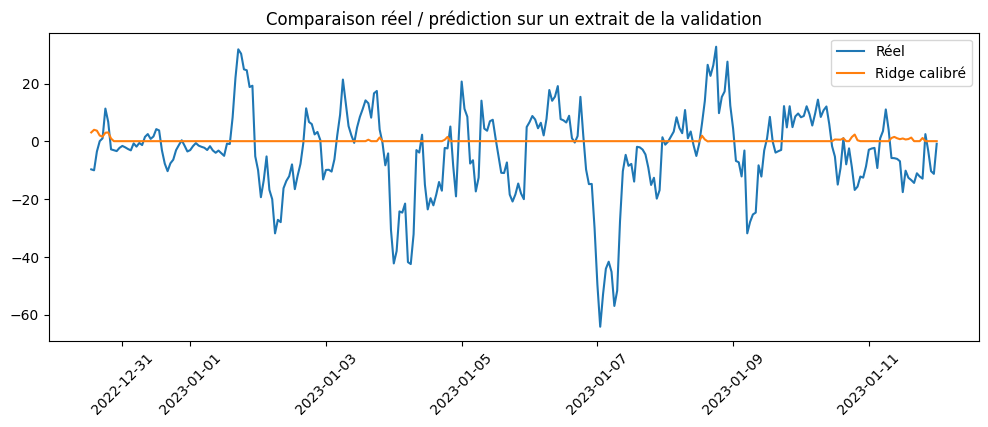

In [24]:
plt.figure(figsize=(12,4))
plt.plot(valid_df[TIME_COL].iloc[:300], valid_df[TARGET_COL].iloc[:300], label="Réel")
plt.plot(ridge_valid_clip[TIME_COL].iloc[:300], ridge_valid_clip[TARGET_COL].iloc[:300], label="Ridge calibré")
plt.xticks(rotation=45)
plt.title("Comparaison réel / prédiction sur un extrait de la validation")
plt.legend()
plt.show()

### Commentaire sur le modèle de référence

Le benchmark "toujours positif" constitue un point de comparaison minimal, particulièrement pertinent ici puisque la métrique dépend du signe de la cible.

La Ridge regression permet de vérifier si les variables construites apportent réellement de l'information prédictive au-delà de ce biais directionnel simple.

La calibration `positive_clip` améliore la Weighted Accuracy lorsque le modèle brut produit des prédictions négatives pénalisantes sur le signe.

## 5. Modèle non supervisé : clustering KMeans

L'objectif est ici de construire un modèle non supervisé au sens de la consigne.

L'approche retenue est la suivante :
1. on standardise les variables numériques ;
2. on applique KMeans ;
3. chaque cluster est ensuite associé à la moyenne de `spot_id_delta` observée sur l'échantillon d'estimation ;
4. les prédictions sur validation sont obtenues en affectant chaque observation au cluster le plus proche.

Cette approche permet de transformer un clustering en règle de prédiction simple.

In [25]:
@dataclass
class KMeansClusterModel:
    n_clusters: int
    init: str
    n_init: int
    random_state: int
    preprocessor: Preprocessor
    kmeans: KMeans
    cluster_values_: np.ndarray
    global_mean_: float
    inertia_: float


def _compute_cluster_values(labels: np.ndarray, y: np.ndarray, n_clusters: int):
    global_mean = float(np.mean(y))
    cluster_values = np.full(n_clusters, global_mean, dtype=float)
    for c in range(n_clusters):
        mask = labels == c
        if np.any(mask):
            cluster_values[c] = float(np.mean(y[mask]))
    return cluster_values, global_mean


def fit_kmeans_regression(train_df, valid_df, ks, scorer, init="k-means++", n_init=20, random_state=42):
    feature_cols = select_feature_columns(train_df)
    prep = fit_preprocessor(train_df, feature_cols)

    x_train = transform_features(train_df, prep)
    y_train = train_df[TARGET_COL].to_numpy(dtype=float)

    x_valid = transform_features(valid_df, prep)
    y_valid = valid_df[TARGET_COL].to_numpy(dtype=float)

    rows = []
    best = None
    best_score = -np.inf
    best_rmse = np.inf

    for k in ks:
        km = KMeans(
            n_clusters=int(k),
            init=init,
            n_init=int(n_init),
            random_state=int(random_state),
            algorithm="lloyd",
        )
        train_labels = km.fit_predict(x_train)
        cluster_values, global_mean = _compute_cluster_values(train_labels, y_train, int(k))

        valid_labels = km.predict(x_valid)
        y_pred = cluster_values[valid_labels]

        score = float(scorer(y_valid, y_pred))
        rmse = float(np.sqrt(np.mean((y_valid - y_pred) ** 2)))
        mae = float(np.mean(np.abs(y_valid - y_pred)))

        rows.append({
            "k": int(k),
            "weighted_accuracy": score,
            "rmse": rmse,
            "mae": mae,
            "inertia": float(km.inertia_),
        })

        if (score > best_score) or (np.isclose(score, best_score) and rmse < best_rmse):
            best_score = score
            best_rmse = rmse
            best = KMeansClusterModel(
                n_clusters=int(k),
                init=init,
                n_init=int(n_init),
                random_state=int(random_state),
                preprocessor=prep,
                kmeans=km,
                cluster_values_=cluster_values,
                global_mean_=global_mean,
                inertia_=float(km.inertia_),
            )

    diagnostics = pd.DataFrame(rows).sort_values(["weighted_accuracy", "rmse"], ascending=[False, True])
    return best, diagnostics


def predict_kmeans(df: pd.DataFrame, model: KMeansClusterModel) -> pd.DataFrame:
    x = transform_features(df, model.preprocessor)
    labels = model.kmeans.predict(x)
    y_pred = model.cluster_values_[labels]
    return pd.DataFrame({TIME_COL: df[TIME_COL], TARGET_COL: y_pred, "cluster": labels})

In [29]:
k_grid = list(range(2, 20))
kmeans_model, kmeans_diag = fit_kmeans_regression(train_df, valid_df, k_grid, weighted_accuracy)

display(kmeans_diag)
print("k retenu :", kmeans_model.n_clusters)

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


,k,weighted_accuracy,rmse,mae,inertia
10,12,0.587328,17.468059,11.907111,111865.934389
11,13,0.565626,17.739122,12.203814,108902.584746
16,18,0.538356,17.845606,12.277557,98433.048515
9,11,0.523148,17.503599,11.867938,114587.270525
8,10,0.518471,17.412753,11.762253,117942.268537
7,9,0.512514,17.482745,11.831973,122174.153051
17,19,0.505243,17.767000,12.198334,96851.754569
15,17,0.503205,17.660909,12.005899,100002.874462
6,8,0.493715,17.266026,11.645737,126250.989830
13,15,0.492794,17.667157,12.041703,103901.118623


k retenu : 12


In [30]:
kmeans_valid_pred = predict_kmeans(valid_df, kmeans_model)

kmeans_metrics = regression_metrics(valid_df[TARGET_COL], kmeans_valid_pred[TARGET_COL]).to_frame(name="KMeans")
display(kmeans_metrics)

,KMeans
WA,0.587328
RMSE,17.468059
MAE,11.907111


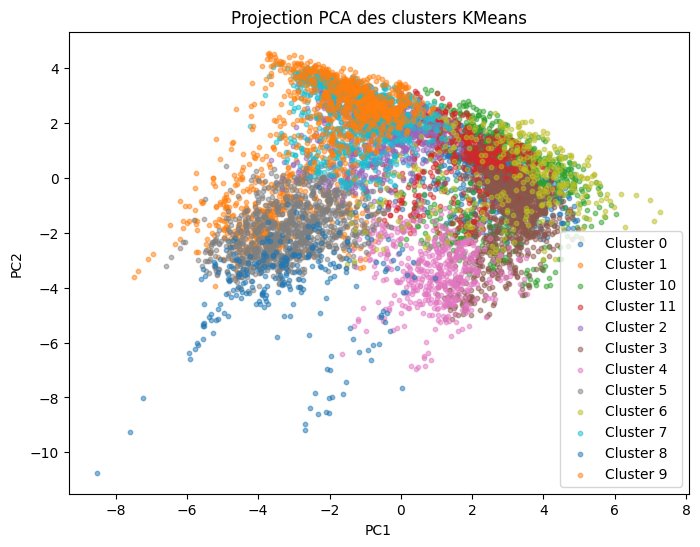

In [31]:
x_train_scaled = transform_features(train_df, kmeans_model.preprocessor)
train_labels = kmeans_model.kmeans.predict(x_train_scaled)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(x_train_scaled)

plot_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "cluster": train_labels.astype(str)
})

plt.figure(figsize=(8,6))
for c in sorted(plot_df["cluster"].unique()):
    sub = plot_df[plot_df["cluster"] == c]
    plt.scatter(sub["PC1"], sub["PC2"], s=10, alpha=0.5, label=f"Cluster {c}")
plt.title("Projection PCA des clusters KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [32]:
cluster_profile = (
    pd.DataFrame({
        "cluster": train_labels,
        TARGET_COL: train_df[TARGET_COL].to_numpy()
    })
    .groupby("cluster")[TARGET_COL]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .reset_index()
)

display(cluster_profile)

,cluster,mean,median,std,min,max,count
0,0,-7.505174,-2.769254,80.148063,-1567.353547,143.065378,783
1,1,-3.998243,-2.923835,31.112766,-132.588609,134.522407,528
2,2,6.384804,2.018525,48.918555,-168.834487,658.961329,982
3,3,0.633407,-1.839466,25.707063,-102.461450,295.162323,758
4,4,3.861810,1.731455,22.318812,-91.791739,163.796107,509
5,5,1.928116,-0.016508,51.181373,-200.842555,477.681225,1051
6,6,1.396796,0.217766,28.222096,-122.999692,107.548210,368
7,7,1.636608,0.440268,30.061009,-229.077280,151.025144,1079
8,8,5.553563,1.159509,44.170206,-135.068311,256.801985,250
9,9,-5.693784,-3.720980,30.285251,-150.451089,131.191420,804


### Commentaire sur le modèle non supervisé

Le clustering permet d'identifier plusieurs régimes de marché distincts dans l'espace des variables explicatives.

Cette approche reste cependant indirecte pour une tâche de prédiction, puisque le modèle ne minimise pas explicitement une erreur de régression.  
Elle est donc surtout intéressante comme outil exploratoire et comme réponse méthodologique à l'exigence d'un modèle non supervisé.

## 6. Modèle supervisé avancé : SVR

Le modèle supervisé avancé retenu est un **Support Vector Regressor (SVR)** à noyau RBF.

Ce choix est pertinent car :
- il autorise des relations non linéaires entre les variables explicatives et la cible ;
- il reste bien adapté à des données numériques standardisées ;
- il permet un réglage fin via les hyperparamètres `C`, `epsilon` et `gamma`.

La sélection des hyperparamètres est effectuée par validation croisée temporelle.

In [33]:
def safe_transform_features(df: pd.DataFrame, prep: Preprocessor) -> np.ndarray:
    missing = [c for c in prep.feature_cols if c not in df.columns]
    if missing:
        print(f"Colonnes manquantes dans df : {missing}")

    n_rows = len(df)
    n_features = len(prep.feature_cols)
    x = np.empty((n_rows, n_features), dtype=float)

    for idx, col in enumerate(prep.feature_cols):
        if col in df.columns:
            x[:, idx] = df[col].to_numpy(dtype=float)
        else:
            x[:, idx] = np.nan

    x = np.where(np.isnan(x), prep.medians, x)
    x = (x - prep.means) / prep.stds
    return x


@dataclass
class SVRModel:
    c: float
    epsilon: float
    gamma: float | str
    kernel: str
    preprocessor: Preprocessor
    model: SVR


def fit_svr(train_df, valid_df, c_values, epsilon_values, gamma_values, scorer, kernel="rbf"):
    feature_cols = select_feature_columns(train_df)
    prep = fit_preprocessor(train_df, feature_cols)

    x_train = safe_transform_features(train_df, prep)
    y_train = train_df[TARGET_COL].to_numpy(dtype=float)

    skip_validation = valid_df is None or valid_df.empty
    if skip_validation:
        c = float(c_values[0])
        epsilon = float(epsilon_values[0])
        gamma = gamma_values[0]
        model = SVR(kernel=kernel, C=c, epsilon=epsilon, gamma=gamma)
        model.fit(x_train, y_train)

        diagnostics = pd.DataFrame([{
            "kernel": kernel,
            "C": c,
            "epsilon": epsilon,
            "gamma": gamma
        }])

        best_model = SVRModel(
            c=c,
            epsilon=epsilon,
            gamma=gamma,
            kernel=kernel,
            preprocessor=prep,
            model=model,
        )
        return best_model, diagnostics

    x_valid = safe_transform_features(valid_df, prep)
    y_valid = valid_df[TARGET_COL].to_numpy(dtype=float)

    rows = []
    best_model = None
    best_score = -np.inf
    best_rmse = np.inf

    for c in c_values:
        for epsilon in epsilon_values:
            for gamma in gamma_values:
                model = SVR(kernel=kernel, C=float(c), epsilon=float(epsilon), gamma=gamma)
                model.fit(x_train, y_train)
                y_pred = model.predict(x_valid)

                score = float(scorer(y_valid, y_pred))
                rmse = float(np.sqrt(np.mean((y_valid - y_pred) ** 2)))
                mae = float(np.mean(np.abs(y_valid - y_pred)))

                rows.append({
                    "kernel": kernel,
                    "C": float(c),
                    "epsilon": float(epsilon),
                    "gamma": gamma,
                    "weighted_accuracy": score,
                    "rmse": rmse,
                    "mae": mae,
                })

                if score > best_score or (np.isclose(score, best_score) and rmse < best_rmse):
                    best_score = score
                    best_rmse = rmse
                    best_model = SVRModel(
                        c=float(c),
                        epsilon=float(epsilon),
                        gamma=gamma,
                        kernel=kernel,
                        preprocessor=prep,
                        model=model,
                    )

    diagnostics = pd.DataFrame(rows).sort_values(["weighted_accuracy", "rmse"], ascending=[False, True])
    return best_model, diagnostics


def predict_svr(df: pd.DataFrame, model: SVRModel) -> pd.DataFrame:
    x = safe_transform_features(df, model.preprocessor)
    y_pred = model.model.predict(x)
    return pd.DataFrame({TIME_COL: df[TIME_COL], TARGET_COL: y_pred})

In [34]:
def timeseries_cv_search(train_df, c_values, epsilon_values, gamma_values, n_splits=3, kernel="rbf"):
    ordered = train_df.sort_values(TIME_COL).reset_index(drop=True).copy()
    tscv = TimeSeriesSplit(n_splits=n_splits)

    rows = []

    for c in c_values:
        for epsilon in epsilon_values:
            for gamma in gamma_values:
                for fold_id, (tr_idx, va_idx) in enumerate(tscv.split(ordered), start=1):
                    fold_train = ordered.iloc[tr_idx].copy()
                    fold_valid = ordered.iloc[va_idx].copy()

                    model, _ = fit_svr(
                        train_df=fold_train,
                        valid_df=fold_valid,
                        c_values=[c],
                        epsilon_values=[epsilon],
                        gamma_values=[gamma],
                        scorer=weighted_accuracy,
                        kernel=kernel,
                    )

                    train_pred = predict_svr(fold_train, model)
                    valid_pred = predict_svr(fold_valid, model)

                    y_train = fold_train[TARGET_COL].to_numpy(dtype=float)
                    y_valid = fold_valid[TARGET_COL].to_numpy(dtype=float)

                    rows.append({
                        "C": c,
                        "epsilon": epsilon,
                        "gamma": gamma,
                        "fold": fold_id,
                        "train_wa": regression_metrics(y_train, train_pred[TARGET_COL])["WA"],
                        "valid_wa": regression_metrics(y_valid, valid_pred[TARGET_COL])["WA"],
                        "train_rmse": regression_metrics(y_train, train_pred[TARGET_COL])["RMSE"],
                        "valid_rmse": regression_metrics(y_valid, valid_pred[TARGET_COL])["RMSE"],
                    })

    cv_detail = pd.DataFrame(rows)
    cv_summary = (
        cv_detail.groupby(["C", "epsilon", "gamma"], as_index=False)
        .agg(
            cv_valid_wa_mean=("valid_wa", "mean"),
            cv_valid_wa_std=("valid_wa", "std"),
            cv_valid_rmse_mean=("valid_rmse", "mean"),
            cv_train_wa_mean=("train_wa", "mean"),
        )
        .sort_values(["cv_valid_wa_mean", "cv_valid_rmse_mean"], ascending=[False, True])
        .reset_index(drop=True)
    )

    best = cv_summary.iloc[0]
    final_model, _ = fit_svr(
        train_df=train_df,
        valid_df=pd.DataFrame(),
        c_values=[best["C"]],
        epsilon_values=[best["epsilon"]],
        gamma_values=[best["gamma"]],
        scorer=weighted_accuracy,
        kernel=kernel,
    )

    return cv_detail, cv_summary, final_model

In [35]:
c_grid = [0.1, 1, 10]
eps_grid = [0.01, 0.1]
gamma_grid = ["scale", 0.01, 0.1]

svr_cv_detail, svr_cv_summary, svr_model = timeseries_cv_search(
    train_df=train_df,
    c_values=c_grid,
    epsilon_values=eps_grid,
    gamma_values=gamma_grid,
    n_splits=3,
    kernel="rbf"
)

display(svr_cv_summary.head(10))
print("Meilleurs hyperparamètres :")
print("C =", svr_model.c)
print("epsilon =", svr_model.epsilon)
print("gamma =", svr_model.gamma)

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
 

,C,epsilon,gamma,cv_valid_wa_mean,cv_valid_wa_std,cv_valid_rmse_mean,cv_train_wa_mean
0,10.0,0.01,0.1,0.532325,0.051975,44.931305,0.904318
1,10.0,0.10,0.1,0.532283,0.051515,44.931514,0.904517
2,1.0,0.10,0.1,0.513097,0.076279,44.602448,0.814828
3,1.0,0.01,0.1,0.512495,0.076787,44.602119,0.814819
4,1.0,0.01,scale,0.505741,0.078659,44.841674,0.745002
5,1.0,0.10,scale,0.503649,0.080257,44.842497,0.745704
6,0.1,0.01,0.01,0.498646,0.107708,44.606871,0.570918
7,0.1,0.10,0.01,0.497097,0.108041,44.606372,0.571391
8,10.0,0.01,scale,0.492530,0.043918,45.922957,0.835341
9,10.0,0.10,scale,0.491761,0.044738,45.925919,0.835642


Meilleurs hyperparamètres :
C = 10.0
epsilon = 0.01
gamma = 0.1


In [36]:
svr_valid_pred = predict_svr(valid_df, svr_model)
svr_metrics = regression_metrics(valid_df[TARGET_COL], svr_valid_pred[TARGET_COL]).to_frame(name="SVR")
display(svr_metrics)

,SVR
WA,0.635879
RMSE,17.052738
MAE,11.416266


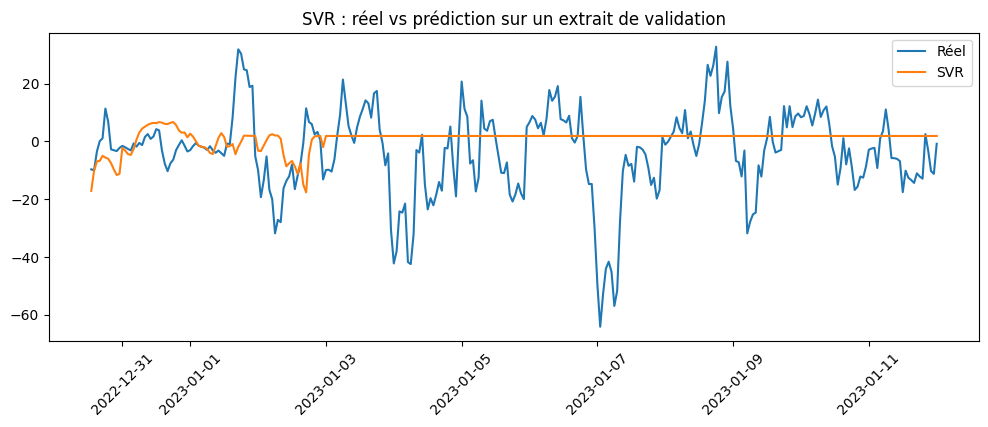

In [37]:
plt.figure(figsize=(12,4))
plt.plot(valid_df[TIME_COL].iloc[:300], valid_df[TARGET_COL].iloc[:300], label="Réel")
plt.plot(svr_valid_pred[TIME_COL].iloc[:300], svr_valid_pred[TARGET_COL].iloc[:300], label="SVR")
plt.xticks(rotation=45)
plt.title("SVR : réel vs prédiction sur un extrait de validation")
plt.legend()
plt.show()

## 6 bis. Modèles supervisés ensemblistes : Random Forest, LightGBM et XGBoost

En complément du SVR, plusieurs méthodes ensemblistes sont testées afin d'identifier un modèle supervisé potentiellement plus performant.

Les trois approches retenues sont :
- **Random Forest Regressor** : robuste, simple à interpréter, capable de capturer des non-linéarités ;
- **LightGBM Regressor** : méthode de gradient boosting efficace sur variables numériques ;
- **XGBoost Regressor** : autre méthode de boosting puissante, souvent performante sur des tâches tabulaires.

L'objectif est de comparer ces trois familles, puis de retenir le meilleur modèle selon la métrique principale du projet : la **Weighted Accuracy** sur validation chronologique.

In [39]:
from dataclasses import dataclass

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM n'est pas installé.")

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost n'est pas installé.")

### Préprocessing

Comme pour les modèles précédents, le préprocessing est estimé uniquement sur l'échantillon d'entraînement de chaque fold :
- sélection des colonnes numériques,
- imputation des valeurs manquantes par la médiane du train,
- standardisation.

Même si les modèles en arbres sont moins sensibles à l'échelle, conserver une procédure homogène facilite la comparaison avec les modèles précédents.

In [40]:
@dataclass
class TreeModelWrapper:
    model_name: str
    params: dict
    preprocessor: Preprocessor
    model: object


def predict_tree_model(df: pd.DataFrame, wrapped_model: TreeModelWrapper) -> pd.DataFrame:
    x = transform_features(df, wrapped_model.preprocessor)
    y_pred = wrapped_model.model.predict(x)
    return pd.DataFrame({
        TIME_COL: df[TIME_COL].copy(),
        TARGET_COL: y_pred
    })

In [41]:
def build_model(model_name: str, params: dict, random_state: int = 42):
    if model_name == "RandomForest":
        return RandomForestRegressor(
            random_state=random_state,
            n_jobs=-1,
            **params
        )

    if model_name == "LightGBM":
        if not LIGHTGBM_AVAILABLE:
            raise ImportError("LightGBM n'est pas installé.")
        return LGBMRegressor(
            random_state=random_state,
            verbosity=-1,
            **params
        )

    if model_name == "XGBoost":
        if not XGBOOST_AVAILABLE:
            raise ImportError("XGBoost n'est pas installé.")
        return XGBRegressor(
            random_state=random_state,
            n_jobs=-1,
            objective="reg:squarederror",
            verbosity=0,
            **params
        )

    raise ValueError(f"Modèle inconnu : {model_name}")

In [42]:
def fit_single_tree_model(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    model_name: str,
    params: dict,
    random_state: int = 42,
) -> tuple[TreeModelWrapper, dict]:
    feature_cols = select_feature_columns(train_df)
    prep = fit_preprocessor(train_df, feature_cols)

    x_train = transform_features(train_df, prep)
    y_train = train_df[TARGET_COL].to_numpy(dtype=float)

    x_valid = transform_features(valid_df, prep)
    y_valid = valid_df[TARGET_COL].to_numpy(dtype=float)

    model = build_model(model_name, params, random_state=random_state)
    model.fit(x_train, y_train)

    y_hat_train = model.predict(x_train)
    y_hat_valid = model.predict(x_valid)

    train_metrics = regression_metrics(y_train, y_hat_train)
    valid_metrics = regression_metrics(y_valid, y_hat_valid)

    wrapped = TreeModelWrapper(
        model_name=model_name,
        params=params,
        preprocessor=prep,
        model=model
    )

    metrics = {
        "model_name": model_name,
        **params,
        "train_WA": float(train_metrics["WA"]),
        "train_RMSE": float(train_metrics["RMSE"]),
        "train_MAE": float(train_metrics["MAE"]),
        "valid_WA": float(valid_metrics["WA"]),
        "valid_RMSE": float(valid_metrics["RMSE"]),
        "valid_MAE": float(valid_metrics["MAE"]),
        "WA_gap": float(train_metrics["WA"] - valid_metrics["WA"]),
        "RMSE_gap": float(valid_metrics["RMSE"] - train_metrics["RMSE"]),
    }

    return wrapped, metrics

### Validation croisée temporelle et grid search

Pour chaque modèle, plusieurs combinaisons d'hyperparamètres sont testées avec une validation croisée temporelle.  
Le critère principal de sélection est :
1. la **WA moyenne en validation** ;
2. puis, à égalité, le **RMSE moyen en validation** ;
3. enfin, on surveille l'écart **train / validation** pour détecter le surapprentissage.

In [43]:
def expand_param_grid(param_grid: dict) -> list[dict]:
    from itertools import product

    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]
    combos = []

    for combination in product(*values):
        combos.append(dict(zip(keys, combination)))

    return combos

In [48]:
def timeseries_cv_search_tree_model(
    train_df: pd.DataFrame,
    model_name: str,
    param_grid: dict,
    n_splits: int = 3,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, TreeModelWrapper]:
    ordered = train_df.sort_values(TIME_COL).reset_index(drop=True).copy()
    tscv = TimeSeriesSplit(n_splits=n_splits)

    param_combinations = expand_param_grid(param_grid)
    rows = []

    print(f"\n {model_name} - {len(param_combinations)} configurations testées avec {n_splits} folds")

    for param_id, params in enumerate(param_combinations, start=1):
        print(f"   Configuration {param_id}/{len(param_combinations)} : {params}")
        for fold_id, (tr_idx, va_idx) in enumerate(tscv.split(ordered), start=1):
            fold_train = ordered.iloc[tr_idx].copy()
            fold_valid = ordered.iloc[va_idx].copy()

            wrapped_model, metrics = fit_single_tree_model(
                train_df=fold_train,
                valid_df=fold_valid,
                model_name=model_name,
                params=params,
                random_state=random_state,
            )

            row = {
                "model_name": model_name,
                "fold": fold_id,
                **params,
                "train_WA": metrics["train_WA"],
                "train_RMSE": metrics["train_RMSE"],
                "train_MAE": metrics["train_MAE"],
                "valid_WA": metrics["valid_WA"],
                "valid_RMSE": metrics["valid_RMSE"],
                "valid_MAE": metrics["valid_MAE"],
                "WA_gap": metrics["WA_gap"],
                "RMSE_gap": metrics["RMSE_gap"],
            }
            rows.append(row)

    cv_detail = pd.DataFrame(rows)

    group_cols = ["model_name"] + list(param_grid.keys())

    cv_summary = (
        cv_detail.groupby(group_cols, as_index=False)
        .agg(
            cv_valid_WA_mean=("valid_WA", "mean"),
            cv_valid_WA_std=("valid_WA", "std"),
            cv_valid_RMSE_mean=("valid_RMSE", "mean"),
            cv_valid_RMSE_std=("valid_RMSE", "std"),
            cv_train_WA_mean=("train_WA", "mean"),
            cv_train_RMSE_mean=("train_RMSE", "mean"),
            cv_WA_gap_mean=("WA_gap", "mean"),
            cv_WA_gap_std=("WA_gap", "std"),
        )
        .sort_values(
            ["cv_valid_WA_mean", "cv_valid_WA_std", "cv_valid_RMSE_mean"],
            ascending=[False, True, True]
        )
        .reset_index(drop=True)
    )

    best_row = cv_summary.iloc[0]
    best_params = {}

    for k in param_grid.keys():
        val = best_row[k]

        if pd.isna(val):
            val = None

        # cast automatique propre
        if isinstance(val, (np.floating, float)):
            if val.is_integer():
                val = int(val)
            else:
                val = float(val)

        best_params[k] = val

    best_model, _ = fit_single_tree_model(
        train_df=train_df,
        valid_df=valid_df,
        model_name=model_name,
        params=best_params,
        random_state=random_state,
    )

    print(f"Meilleure configuration {model_name} : {best_params}")
    print(
        f"   WA CV = {best_row['cv_valid_WA_mean']:.4f} ± {best_row['cv_valid_WA_std']:.4f} | "
        f"gap train-valid = {best_row['cv_WA_gap_mean']:.4f}"
    )

    return cv_detail, cv_summary, best_model

In [49]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [6, 12, None],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", 0.5],
}

lgbm_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 6, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

In [50]:
rf_cv_detail, rf_cv_summary, rf_model = timeseries_cv_search_tree_model(
    train_df=train_df,
    model_name="RandomForest",
    param_grid=rf_param_grid,
    n_splits=3,
    random_state=42,
)

display(rf_cv_summary.head(10))


 RandomForest - 24 configurations testées avec 3 folds
   Configuration 1/24 : {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


   Configuration 2/24 : {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 1, 'max_features': 0.5}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


   Configuration 3/24 : {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


...

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


   Configuration 24/24 : {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 0.5}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Meilleure configuration RandomForest : {'n_estimators': np.int64(200), 'max_depth': 12, 'min_samples_leaf': np.int64(5), 'max_features': 'sqrt'}
   WA CV = 0.4903 ± 0.0427 | gap train-valid = 0.4411


,model_name,n_estimators,max_depth,min_samples_leaf,max_features,cv_valid_WA_mean,cv_valid_WA_std,cv_valid_RMSE_mean,cv_valid_RMSE_std,cv_train_WA_mean,cv_train_RMSE_mean,cv_WA_gap_mean,cv_WA_gap_std
0,RandomForest,200,12.0,5,sqrt,0.490347,0.042666,48.586417,14.761801,0.931435,25.364747,0.441089,0.036940
1,RandomForest,200,12.0,5,0.5,0.485870,0.007951,50.894389,16.925424,0.928909,24.384507,0.443039,0.013019
2,RandomForest,400,12.0,5,0.5,0.485801,0.013303,50.821881,16.700638,0.930360,24.180538,0.444559,0.015859
3,RandomForest,200,12.0,1,sqrt,0.483612,0.005315,50.779671,14.704610,0.949144,15.527837,0.465532,0.006050
4,RandomForest,200,12.0,1,0.5,0.479899,0.026500,54.856170,16.595209,0.937022,15.692630,0.457123,0.019678
5,RandomForest,400,12.0,1,0.5,0.479246,0.019709,54.950843,15.588553,0.937454,15.494804,0.458208,0.016262
6,RandomForest,400,12.0,1,sqrt,0.476036,0.007471,50.395598,15.588690,0.950840,15.423165,0.474803,0.002852
7,RandomForest,200,6.0,1,sqrt,0.475176,0.026712,49.721692,14.513022,0.814445,24.449678,0.339269,0.021544
8,RandomForest,400,6.0,1,0.5,0.474343,0.026698,53.114706,17.307512,0.797193,23.785387,0.322850,0.020975
9,RandomForest,400,6.0,5,0.5,0.474140,0.030550,50.474584,17.371673,0.797081,29.073835,0.322941,0.031341


In [51]:
if LIGHTGBM_AVAILABLE:
    lgbm_cv_detail, lgbm_cv_summary, lgbm_model = timeseries_cv_search_tree_model(
        train_df=train_df,
        model_name="LightGBM",
        param_grid=lgbm_param_grid,
        n_splits=3,
        random_state=42,
    )
    display(lgbm_cv_summary.head(10))
else:
    lgbm_cv_detail, lgbm_cv_summary, lgbm_model = None, None, None


 LightGBM - 216 configurations testées avec 3 folds
   Configuration 1/216 : {'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'subsample': 0.8, 'colsample_bytree': 0.8}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have va

   Configuration 2/216 : {'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'subsample': 0.8, 'colsample_bytree': 1.0}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have va

   Configuration 3/216 : {'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'subsample': 1.0, 'colsample_bytree': 0.8}


...

   Configuration 216/216 : {'n_estimators': 400, 'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': 10, 'subsample': 1.0, 'colsample_bytree': 1.0}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not

Meilleure configuration LightGBM : {'n_estimators': np.int64(200), 'learning_rate': 0.05, 'num_leaves': np.int64(63), 'max_depth': np.int64(-1), 'subsample': 0.8, 'colsample_bytree': 0.8}
   WA CV = 0.5166 ± 0.0735 | gap train-valid = 0.4573


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model_name,n_estimators,learning_rate,num_leaves,max_depth,subsample,colsample_bytree,cv_valid_WA_mean,cv_valid_WA_std,cv_valid_RMSE_mean,cv_valid_RMSE_std,cv_train_WA_mean,cv_train_RMSE_mean,cv_WA_gap_mean,cv_WA_gap_std
0,LightGBM,200,0.05,63,-1,0.8,0.8,0.516630,0.073482,51.252017,15.263190,0.973937,14.773472,0.457307,0.065084
1,LightGBM,200,0.05,63,-1,1.0,0.8,0.516630,0.073482,51.252017,15.263190,0.973937,14.773472,0.457307,0.065084
2,LightGBM,400,0.10,63,-1,0.8,1.0,0.511985,0.045498,52.250664,14.886442,0.996948,3.781494,0.484963,0.045438
3,LightGBM,400,0.10,63,-1,1.0,1.0,0.511985,0.045498,52.250664,14.886442,0.996948,3.781494,0.484963,0.045438
4,LightGBM,400,0.05,63,-1,0.8,0.8,0.509342,0.047429,51.938674,15.271380,0.989086,9.041596,0.479744,0.044212
5,LightGBM,400,0.05,63,-1,1.0,0.8,0.509342,0.047429,51.938674,15.271380,0.989086,9.041596,0.479744,0.044212
6,LightGBM,400,0.10,31,10,0.8,1.0,0.507720,0.052646,52.441046,14.523790,0.986891,6.563891,0.479171,0.050624
7,LightGBM,400,0.10,31,10,1.0,1.0,0.507720,0.052646,52.441046,14.523790,0.986891,6.563891,0.479171,0.050624
8,LightGBM,200,0.10,63,-1,0.8,1.0,0.506860,0.041514,52.123127,14.781478,0.988450,8.850684,0.481590,0.037191
9,LightGBM,200,0.10,63,-1,1.0,1.0,0.506860,0.041514,52.123127,14.781478,0.988450,8.850684,0.481590,0.037191


In [52]:
if XGBOOST_AVAILABLE:
    xgb_cv_detail, xgb_cv_summary, xgb_model = timeseries_cv_search_tree_model(
        train_df=train_df,
        model_name="XGBoost",
        param_grid=xgb_param_grid,
        n_splits=3,
        random_state=42,
    )
    display(xgb_cv_summary.head(10))
else:
    xgb_cv_detail, xgb_cv_summary, xgb_model = None, None, None

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,



 XGBoost - 72 configurations testées avec 3 folds
   Configuration 1/72 : {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


   Configuration 2/72 : {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


...

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


   Configuration 72/72 : {'n_estimators': 400, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 1.0, 'colsample_bytree': 1.0}


C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Meilleure configuration XGBoost : {'n_estimators': np.int64(400), 'learning_rate': 0.05, 'max_depth': np.int64(5), 'subsample': 1, 'colsample_bytree': 1}
   WA CV = 0.5157 ± 0.0662 | gap train-valid = 0.4377


,model_name,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,cv_valid_WA_mean,cv_valid_WA_std,cv_valid_RMSE_mean,cv_valid_RMSE_std,cv_train_WA_mean,cv_train_RMSE_mean,cv_WA_gap_mean,cv_WA_gap_std
0,XGBoost,400,0.05,5,1.0,1.0,0.515746,0.066218,53.238369,13.933265,0.953438,10.212414,0.437692,0.050176
1,XGBoost,400,0.10,3,0.8,0.8,0.508123,0.023471,55.915066,16.603058,0.912365,13.996527,0.404243,0.059141
2,XGBoost,400,0.10,5,1.0,1.0,0.507253,0.034470,51.733185,14.353929,0.981817,6.327501,0.474564,0.027850
3,XGBoost,200,0.10,5,1.0,1.0,0.503255,0.034796,51.457487,14.561956,0.955084,10.111536,0.451828,0.027141
4,XGBoost,200,0.05,5,1.0,1.0,0.502928,0.076173,51.692831,12.681100,0.916493,14.070655,0.413565,0.050665
5,XGBoost,400,0.03,5,1.0,1.0,0.494117,0.041287,51.844824,13.721646,0.928749,12.961948,0.434632,0.020092
6,XGBoost,200,0.05,5,1.0,0.8,0.494071,0.039160,50.967989,15.281227,0.916487,14.200290,0.422416,0.017180
7,XGBoost,400,0.05,7,1.0,1.0,0.490712,0.031970,51.964794,16.508208,0.988797,5.105645,0.498084,0.034108
8,XGBoost,400,0.05,5,1.0,0.8,0.490635,0.046760,51.475546,14.707957,0.954514,10.242512,0.463880,0.035144
9,XGBoost,200,0.03,5,1.0,1.0,0.490325,0.040623,50.631984,13.725548,0.892125,16.528230,0.401800,0.013596


### Comparaison entre Random Forest, LightGBM et XGBoost

On compare maintenant les meilleurs modèles de chaque famille :
- sur la validation croisée temporelle ;
- puis sur l'échantillon de validation final.

Cela permet d'identifier le meilleur candidat ensembliste avant de le comparer au SVR et aux autres modèles précédents.

In [53]:
ensemble_cv_rows = []

best_rf = rf_cv_summary.iloc[0].copy()
ensemble_cv_rows.append({
    "Modèle": "RandomForest",
    "CV WA mean": best_rf["cv_valid_WA_mean"],
    "CV WA std": best_rf["cv_valid_WA_std"],
    "CV RMSE mean": best_rf["cv_valid_RMSE_mean"],
    "CV WA gap mean": best_rf["cv_WA_gap_mean"],
})

if lgbm_cv_summary is not None:
    best_lgbm = lgbm_cv_summary.iloc[0].copy()
    ensemble_cv_rows.append({
        "Modèle": "LightGBM",
        "CV WA mean": best_lgbm["cv_valid_WA_mean"],
        "CV WA std": best_lgbm["cv_valid_WA_std"],
        "CV RMSE mean": best_lgbm["cv_valid_RMSE_mean"],
        "CV WA gap mean": best_lgbm["cv_WA_gap_mean"],
    })

if xgb_cv_summary is not None:
    best_xgb = xgb_cv_summary.iloc[0].copy()
    ensemble_cv_rows.append({
        "Modèle": "XGBoost",
        "CV WA mean": best_xgb["cv_valid_WA_mean"],
        "CV WA std": best_xgb["cv_valid_WA_std"],
        "CV RMSE mean": best_xgb["cv_valid_RMSE_mean"],
        "CV WA gap mean": best_xgb["cv_WA_gap_mean"],
    })

ensemble_cv_comparison = pd.DataFrame(ensemble_cv_rows).sort_values(
    ["CV WA mean", "CV WA std", "CV RMSE mean"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(ensemble_cv_comparison)

,Modèle,CV WA mean,CV WA std,CV RMSE mean,CV WA gap mean
0,LightGBM,0.516630,0.073482,51.252017,0.457307
1,XGBoost,0.515746,0.066218,53.238369,0.437692
2,RandomForest,0.490347,0.042666,48.586417,0.441089


In [54]:
rf_valid_pred = predict_tree_model(valid_df, rf_model)
rf_valid_metrics = regression_metrics(valid_df[TARGET_COL], rf_valid_pred[TARGET_COL])

ensemble_valid_rows = [{
    "Modèle": "RandomForest",
    "WA": rf_valid_metrics["WA"],
    "RMSE": rf_valid_metrics["RMSE"],
    "MAE": rf_valid_metrics["MAE"],
}]

if lgbm_model is not None:
    lgbm_valid_pred = predict_tree_model(valid_df, lgbm_model)
    lgbm_valid_metrics = regression_metrics(valid_df[TARGET_COL], lgbm_valid_pred[TARGET_COL])
    ensemble_valid_rows.append({
        "Modèle": "LightGBM",
        "WA": lgbm_valid_metrics["WA"],
        "RMSE": lgbm_valid_metrics["RMSE"],
        "MAE": lgbm_valid_metrics["MAE"],
    })

if xgb_model is not None:
    xgb_valid_pred = predict_tree_model(valid_df, xgb_model)
    xgb_valid_metrics = regression_metrics(valid_df[TARGET_COL], xgb_valid_pred[TARGET_COL])
    ensemble_valid_rows.append({
        "Modèle": "XGBoost",
        "WA": xgb_valid_metrics["WA"],
        "RMSE": xgb_valid_metrics["RMSE"],
        "MAE": xgb_valid_metrics["MAE"],
    })

ensemble_valid_comparison = pd.DataFrame(ensemble_valid_rows).sort_values(
    ["WA", "RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

display(ensemble_valid_comparison)

C:\Users\Lisa Benkhaled\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modèle,WA,RMSE,MAE
0,RandomForest,0.482050,18.304773,12.470175
1,LightGBM,0.463928,24.168691,16.178833
2,XGBoost,0.460035,22.946407,15.423103


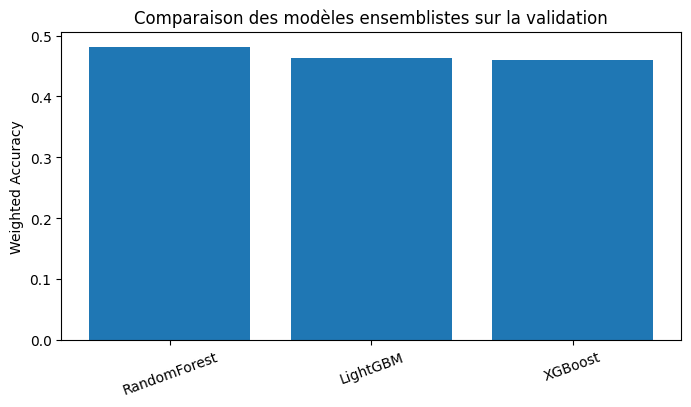

In [55]:
plt.figure(figsize=(8, 4))
plt.bar(ensemble_valid_comparison["Modèle"], ensemble_valid_comparison["WA"])
plt.title("Comparaison des modèles ensemblistes sur la validation")
plt.ylabel("Weighted Accuracy")
plt.xticks(rotation=20)
plt.show()

### Sélection du meilleur modèle ensembliste

Le meilleur modèle ensembliste est retenu en priorité selon :
1. la WA sur validation ;
2. puis le RMSE si nécessaire ;
3. avec une attention particulière portée au gap train / validation afin de détecter un éventuel surapprentissage.

In [56]:
best_ensemble_name = ensemble_valid_comparison.iloc[0]["Modèle"]

if best_ensemble_name == "RandomForest":
    best_ensemble_model = rf_model
    best_ensemble_valid_pred = rf_valid_pred
elif best_ensemble_name == "LightGBM":
    best_ensemble_model = lgbm_model
    best_ensemble_valid_pred = lgbm_valid_pred
else:
    best_ensemble_model = xgb_model
    best_ensemble_valid_pred = xgb_valid_pred

print("Meilleur modèle ensembliste retenu :", best_ensemble_name)
display(regression_metrics(valid_df[TARGET_COL], best_ensemble_valid_pred[TARGET_COL]).to_frame(name=best_ensemble_name))

Meilleur modèle ensembliste retenu : RandomForest


,RandomForest
WA,0.482050
RMSE,18.304773
MAE,12.470175


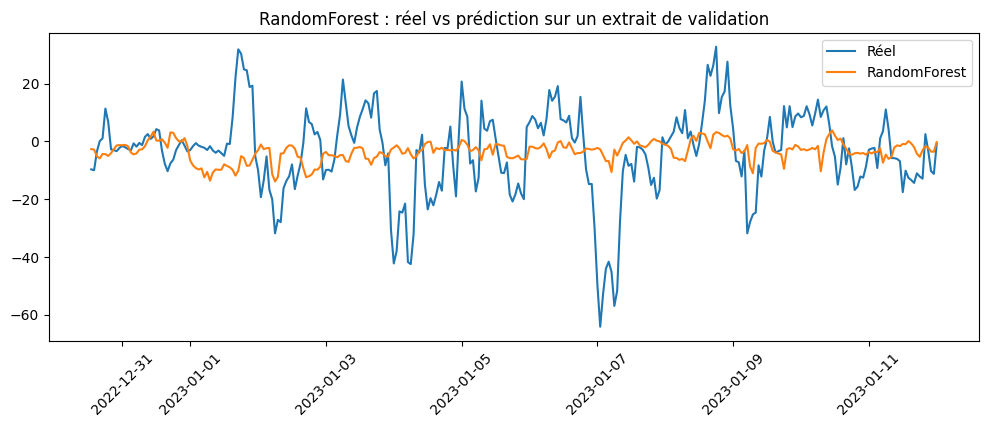

In [57]:
plt.figure(figsize=(12, 4))
plt.plot(valid_df[TIME_COL].iloc[:300], valid_df[TARGET_COL].iloc[:300], label="Réel")
plt.plot(best_ensemble_valid_pred[TIME_COL].iloc[:300], best_ensemble_valid_pred[TARGET_COL].iloc[:300], label=best_ensemble_name)
plt.xticks(rotation=45)
plt.title(f"{best_ensemble_name} : réel vs prédiction sur un extrait de validation")
plt.legend()
plt.show()

### Vérification de l'absence de surapprentissage

L'absence de surapprentissage n'est jamais absolue, mais elle est évaluée ici à partir :
- de la stabilité de la WA entre les folds ;
- de l'écart moyen entre performance train et validation ;
- de la cohérence entre CV temporelle et validation finale.

Un modèle présentant une très forte performance en train mais une nette dégradation en validation sera interprété comme potentiellement surappris.

In [58]:
overfit_rows = []

best_rf = rf_cv_summary.iloc[0]
overfit_rows.append({
    "Modèle": "RandomForest",
    "CV WA mean": best_rf["cv_valid_WA_mean"],
    "CV WA std": best_rf["cv_valid_WA_std"],
    "Train-Valid WA gap": best_rf["cv_WA_gap_mean"],
    "Diagnostic": "Surapprentissage modéré ou faible" if abs(best_rf["cv_WA_gap_mean"]) < 0.05 else "Attention au surapprentissage"
})

if lgbm_cv_summary is not None:
    best_lgbm = lgbm_cv_summary.iloc[0]
    overfit_rows.append({
        "Modèle": "LightGBM",
        "CV WA mean": best_lgbm["cv_valid_WA_mean"],
        "CV WA std": best_lgbm["cv_valid_WA_std"],
        "Train-Valid WA gap": best_lgbm["cv_WA_gap_mean"],
        "Diagnostic": "Surapprentissage modéré ou faible" if abs(best_lgbm["cv_WA_gap_mean"]) < 0.05 else "Attention au surapprentissage"
    })

if xgb_cv_summary is not None:
    best_xgb = xgb_cv_summary.iloc[0]
    overfit_rows.append({
        "Modèle": "XGBoost",
        "CV WA mean": best_xgb["cv_valid_WA_mean"],
        "CV WA std": best_xgb["cv_valid_WA_std"],
        "Train-Valid WA gap": best_xgb["cv_WA_gap_mean"],
        "Diagnostic": "Surapprentissage modéré ou faible" if abs(best_xgb["cv_WA_gap_mean"]) < 0.05 else "Attention au surapprentissage"
    })

overfit_table = pd.DataFrame(overfit_rows)
display(overfit_table)

,Modèle,CV WA mean,CV WA std,Train-Valid WA gap,Diagnostic
0,RandomForest,0.490347,0.042666,0.441089,Attention au surapprentissage
1,LightGBM,0.516630,0.073482,0.457307,Attention au surapprentissage
2,XGBoost,0.515746,0.066218,0.437692,Attention au surapprentissage


## Comparaison avec les modèles précédents

Le meilleur modèle ensembliste peut maintenant être comparé :
- au benchmark naïf,
- au modèle de référence Ridge,
- au modèle non supervisé KMeans,
- au SVR.

In [59]:
best_ensemble_metrics = regression_metrics(valid_df[TARGET_COL], best_ensemble_valid_pred[TARGET_COL])

final_comparison_extended = pd.DataFrame({
    "Modèle": [
        "Baseline toujours positive",
        "Ridge brute",
        "Ridge calibrée",
        "KMeans",
        "SVR",
        best_ensemble_name,
    ],
    "WA": [
        regression_metrics(valid_df[TARGET_COL], baseline_valid[TARGET_COL])["WA"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_raw[TARGET_COL])["WA"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_clip[TARGET_COL])["WA"],
        regression_metrics(valid_df[TARGET_COL], kmeans_valid_pred[TARGET_COL])["WA"],
        regression_metrics(valid_df[TARGET_COL], svr_valid_pred[TARGET_COL])["WA"],
        best_ensemble_metrics["WA"],
    ],
    "RMSE": [
        regression_metrics(valid_df[TARGET_COL], baseline_valid[TARGET_COL])["RMSE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_raw[TARGET_COL])["RMSE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_clip[TARGET_COL])["RMSE"],
        regression_metrics(valid_df[TARGET_COL], kmeans_valid_pred[TARGET_COL])["RMSE"],
        regression_metrics(valid_df[TARGET_COL], svr_valid_pred[TARGET_COL])["RMSE"],
        best_ensemble_metrics["RMSE"],
    ],
    "MAE": [
        regression_metrics(valid_df[TARGET_COL], baseline_valid[TARGET_COL])["MAE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_raw[TARGET_COL])["MAE"],
        regression_metrics(valid_df[TARGET_COL], ridge_valid_clip[TARGET_COL])["MAE"],
        regression_metrics(valid_df[TARGET_COL], kmeans_valid_pred[TARGET_COL])["MAE"],
        regression_metrics(valid_df[TARGET_COL], svr_valid_pred[TARGET_COL])["MAE"],
        best_ensemble_metrics["MAE"],
    ],
}).sort_values(["WA", "RMSE"], ascending=[False, True]).reset_index(drop=True)

display(final_comparison_extended)

,Modèle,WA,RMSE,MAE
0,Ridge calibrée,0.658359,16.783985,11.300921
1,Baseline toujours positive,0.658359,16.795445,11.190255
2,SVR,0.635879,17.052738,11.416266
3,KMeans,0.587328,17.468059,11.907111
4,RandomForest,0.482050,18.304773,12.470175
5,Ridge brute,0.466138,18.027602,12.672909


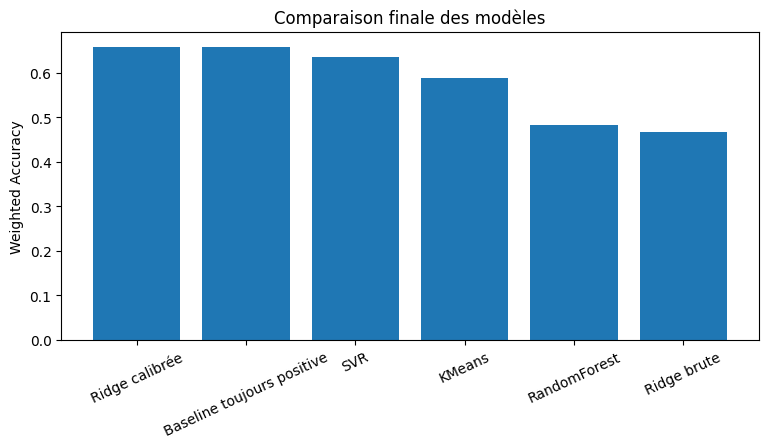

In [60]:
plt.figure(figsize=(9, 4))
plt.bar(final_comparison_extended["Modèle"], final_comparison_extended["WA"])
plt.title("Comparaison finale des modèles")
plt.ylabel("Weighted Accuracy")
plt.xticks(rotation=25)
plt.show()

### Conclusion sur les modèles supervisés

Les modèles ensemblistes permettent de tester des structures plus flexibles que la Ridge et complémentaires du SVR.

La comparaison entre Random Forest, LightGBM et XGBoost permet d'identifier la meilleure famille d'arbres pour ce problème.  
Le modèle retenu est ensuite comparé aux approches précédentes afin de déterminer s'il constitue ou non la meilleure réponse supervisée à la problématique.

## Modélisation avancée : approche hybride signe + amplitude

La métrique Weighted Accuracy dépend principalement du signe de la cible, pondéré par son amplitude.

Nous proposons donc une approche en deux étapes :
1. un modèle de classification pour prédire le signe de l'écart
2. un modèle de régression pour prédire son amplitude

La prédiction finale est reconstruite comme :
ŷ = signe × amplitude

In [ ]:
def make_amplitude_target(y):
    return np.abs(y)

Modèle signe

In [ ]:
TIME_COL = "DELIVERY_START"
TARGET_COL = "spot_id_delta"


def make_sign_target(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    return (y > 0).astype(int)


def train_sign_model(train_df: pd.DataFrame):
    feature_cols = select_feature_columns(train_df)
    prep = fit_preprocessor(train_df, feature_cols)

    X_train = transform_features(train_df, prep)
    y_train = train_df[TARGET_COL].to_numpy(dtype=float)
    y_train_cls = make_sign_target(y_train)

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train_cls,
        sample_weight=np.abs(y_train)
    )

    return model, prep

Modèle amplitude

In [ ]:
def train_amplitude_model(train_df: pd.DataFrame):
    feature_cols = select_feature_columns(train_df)
    prep = fit_preprocessor(train_df, feature_cols)

    X_train = transform_features(train_df, prep)
    y_train_amp = np.abs(train_df[TARGET_COL].to_numpy(dtype=float))

    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train_amp)

    return model, prep

Prédiction finale

In [78]:
def predict_hybrid(
    df: pd.DataFrame,
    sign_model,
    amp_model,
    prep_sign: dict,
    prep_amp: dict,
    time_col: str = "DELIVERY_START",
    target_col: str = "spot_id_delta",
) -> pd.DataFrame:
    X_sign = transform_features(df, prep_sign)
    X_amp = transform_features(df, prep_amp)

    sign_pred_cls = sign_model.predict(X_sign)
    sign_pred = np.where(sign_pred_cls == 1, 1.0, -1.0)

    amp_pred = amp_model.predict(X_amp)
    amp_pred = np.maximum(amp_pred, 0.0)

    y_pred = sign_pred * amp_pred

    return pd.DataFrame({
        time_col: df[time_col].copy(),
        target_col: y_pred
    })

In [80]:
def select_feature_columns(df: pd.DataFrame) -> list[str]:
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    return [c for c in numeric_cols if c != "spot_id_delta"]

Evaluation

In [84]:
sign_model, prep_sign = train_sign_model(train_df)
amp_model, prep_amp = train_amplitude_model(train_df)

hybrid_pred = predict_hybrid(valid_df, sign_model, amp_model, prep_sign, prep_amp)

hybrid_metrics = regression_metrics(
    valid_df[TARGET_COL].to_numpy(dtype=float),
    hybrid_pred[TARGET_COL].to_numpy(dtype=float)
)

display(hybrid_metrics.to_frame(name="Hybrid LGBM"))

TypeError: select_feature_columns() got an unexpected keyword argument 'target_col'